# TSST - Práctica 7: Predicción con redes LSTM

**Alicia Lozano Díez**

## Objetivo

El objetivo de esta práctica es proporcionar una introducción al uso de redes neuronales recurrentes (RNN) y en particular, a las Long Short-Term Memory (LSTM) para el procesamiento de series temporales y su uso en predicción. Para ello, se dividirá en dos partes basadas en dos ejemplos de datos: predicción del número de pasajeros en una aerolínea, y el problema de detección de actividad de voz (Voice Activity Detection, VAD). Esta última incluirá además una introducción al procesamiento de señales de voz.

### Materiales

- Guión (.ipynb) de la práctica - Moodle
- Ejemplos de datos y etiquetas - Moodle
- Listas de entrenamiento y validación VAD - Moodle
- Scripts de descarga de datos - Moodle
- Datos y etiquetas de entrenamiento VAD * - One Drive (https://dauam-my.sharepoint.com/:u:/g/personal/alicia_lozano_uam_es/EeHT_NXP56FLkKffjyOhfa8BqAy3EmIrMkBZ0wnyDAti1g?download=1)
- Datos y etiquetas de validación VAD * - One Drive (https://dauam-my.sharepoint.com/:u:/g/personal/alicia_lozano_uam_es/ESc5XzkpZ3ZBnGFQ6HWdn_UB38NHMOLTLtTcEE_b81Cylw?download=1)


**CUIDADO: Los datos proporcionados son de uso exclusivo para esta práctica. No tiene permiso para copiar, distribuir o utilizar el corpus para ningún otro propósito.**


# Parte 1: Predicción mediante LSTM del número de pasajeros de una aerolínea



## 1.1. Carga y visualización de los datos

Igual que hicimos en la práctica 5, vamos a descargar el fichero con los datos de la base de datos *AirPassengers.csv* de Moodle, que contiene los datos del número de pasajeros de una aerolínea para un período de tiempo.

A continuación, los cargamos en Google Colab y los visualizamos para comprobar que es el resultado esperado:

Text(0.5, 1.0, 'Serie temporal: Air Passengers')

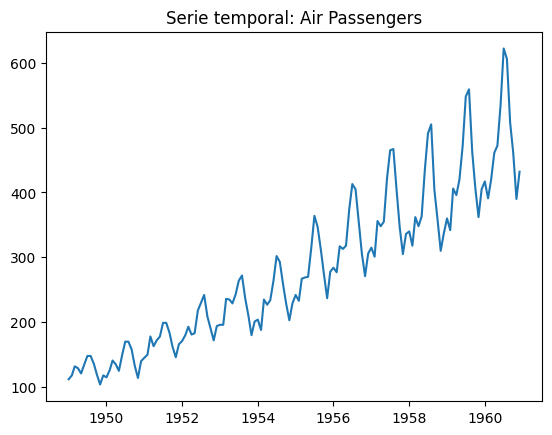

In [123]:
# Carga y visualizacion de los datos
from pandas import read_csv

data = read_csv('AirPassengers.csv', header=0, parse_dates=[0], index_col=0,
                date_format='%Y-%m')

from matplotlib import pyplot as plt
plt.plot(data)
plt.title('Serie temporal: Air Passengers')

## 1.2. Normalización o escalado

Las redes neuronales en general encuentran más dificultades para tratar con datos cuyos valores no tienen algún tipo de normalización.

Por ello, vamos a aplicar un escalado de los datos a valores entre 0 y 1 de la siguiente manera:

Text(0.5, 1.0, 'Serie temporal: Air Passengers (normalizada)')

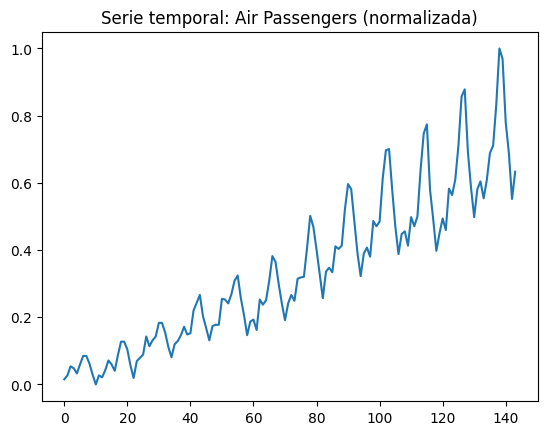

In [124]:
# 2. Normalización de los datos
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
data_norm = scaler.fit_transform(data)

plt.plot(data_norm)
plt.title('Serie temporal: Air Passengers (normalizada)')

## 1.3. Preparación de los datos y definición del modelo LSTM

Para el uso de modelos LSTM, vamos a utilizar la librería Pytorch (https://pytorch.org/docs/stable/index.html).

En particular, vamos a definir un modelo con un número de capas LSTM dadas, y una capa de salida _fully connected_:

In [125]:
# 4. Definición del modelo LSTM
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)  # Salida de la última capa LSTM
        hn = hn[-1]  # Seleccionamos el último estado oculto
        return self.fc(hn)

# Parámetros del modelo
input_size = 1
hidden_size = 20
num_layers = 2
output_size = 1

model = LSTMModel(input_size, hidden_size, num_layers, output_size)

Como se observa, los parámetros utilizados serían los siguientes:

* Tamaño de la entrada a la capa LSTM: input_size
* Unidades (celdas) de la capa LSTM: hidden_size
* Unidades de salida: output_size (capa lineal)

Además, la red LSTM espera un tensor de entrada con el tamaño del batch, la longitud de la secuencia así como la dimensionalidad del espacio de características.

La función forward permite obtener la predicción de la salida para un dato (o batch) de entrada (realiza el paso forward del modelo).

**PREGUNTA 1: Revise la documentación de _torch.nn.LSTM_ y preste atención a los argumentos batch_first, bidirectional y dropout. ¿Para qué sirven dichos argumentos? ¿Cuál es por tanto la dimensionalidad del tensor de entrada esperado en el modelo anterior?**

- batch_first: los datos que vamos a usar, y en general datos que podríamos usar tienen establecidos tensores de la forma $[N, D]$, con $N$ número de muestras y $D$ la dimensión de las mismas. _pytorch_ acepta tensores de la forma $[N, \text{N\_batch}, D]$, donde se introduce una nueva dimensión para los tensores referente al tamaño del batch. Para evitar trasponer dimensiones, se le pasa este parámetro en true, constatando a pytorch que usaremos tensores de la forma $[\text{N\_batch}, N, D]$. 

- bidirectional: permite establecer LSTMs que lean datos en ambas direcciones, no solo de "pasado" a "futuro", también al revés. 

- dropout: se refiere a la tasa de neuronas que se apagarán, únicamente, en el paso forward, para forzar a un aprendizaje más robusto que evite generalizaciones, no pudiendo disponer de todas las neuronas en todos los momentos. En siguientes pasos forward, otras neuronas podrían desactivarse. 

La dimensionalidad del tensor de entrada debería ser de 3. 

Para preparar las secuencias para la red LSTM a partir de los datos, utilizamos el siguiente código, que además divide la serie temporal (nuestros datos) en un 80\% para entrenamiento y un 20\% para test (o validación).

In [126]:
# 3. Preparación de los datos en secuencias para LSTM
import numpy as np
import torch

def create_sequences(data, seq_length):
    sequences = []
    targets = []
    for i in range(len(data) - seq_length):
        seq = data[i:i + seq_length]
        label = data[i + seq_length]
        sequences.append(seq)
        targets.append(label)
    return np.array(sequences), np.array(targets)

seq_length = 12  # Ventana de 12 meses
data = data_norm.squeeze(-1)
X, y = create_sequences(data, seq_length)

# División de datos en entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Conversión a tensores
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


**PREGUNTA 2: Compruebe que las dimensiones de los datos de entrada son las esperadas e indique qué es cada valor.**

In [127]:
X_train.size()

torch.Size([105, 12])

Las dimensiones de entrada no son las esperadas. Tan solo tenemos dos dimensiones referidas a $N$ y $D$. Necesitamos la dimensión referente al tamaño del batch, $\text{N\_batch}$, de forma que los tensores actuales pasen de la forma $[N, D]$ a la adecuada $[\text{N\_batch}, N, D]$, la que intuimos en la pregunta 1. 

A continuación, definimos el resto de parámetros para realizar el entrenamiento del modelo, como son el optimizador, la función de coste y los demás hiperparámetros del entrenamiento.



In [128]:
# 5. Definición del optimizador y función de pérdida
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 6. Entrenamiento del modelo
epochs = 1000
batch_size = 32

**PREGUNTA 3: ¿Qué función de coste se optimiza? ¿Por qué? ¿Qué indica el valor de _batch_size_?**

Se optimiza el MSE. En general, esta función de pérdida se emplea para problemas de regresión donde, a partir de unos datos $\mathcal{D} = \{x_n\}_{n=1}^N$, $x_i\in \mathbb{R}^{D}$ se pretende predecir una clase o target de tipo continuo $y=\{y_n\}_{n=1}^N$, $y_n \in \mathbb{R}$. 

Finalmente realizamos el entrenamiento del modelo durante las épocas indicadas.

In [129]:
# 6. Entrenamiento del modelo

train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size].unsqueeze(-1)  # Añadimos dimensión extra
        y_batch = y_train[i:i+batch_size]

        # Forward
        outputs = model(X_batch)
        loss = criterion(outputs.squeeze(), y_batch)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        train_losses.append(total_loss)

**PREGUNTA 4: ¿Qué observa en la función de pérdida? ¿Tiene sentido? ¿Hacen falta más épocas?**

Es fácil observar que la función de pérdida se estabiliza:

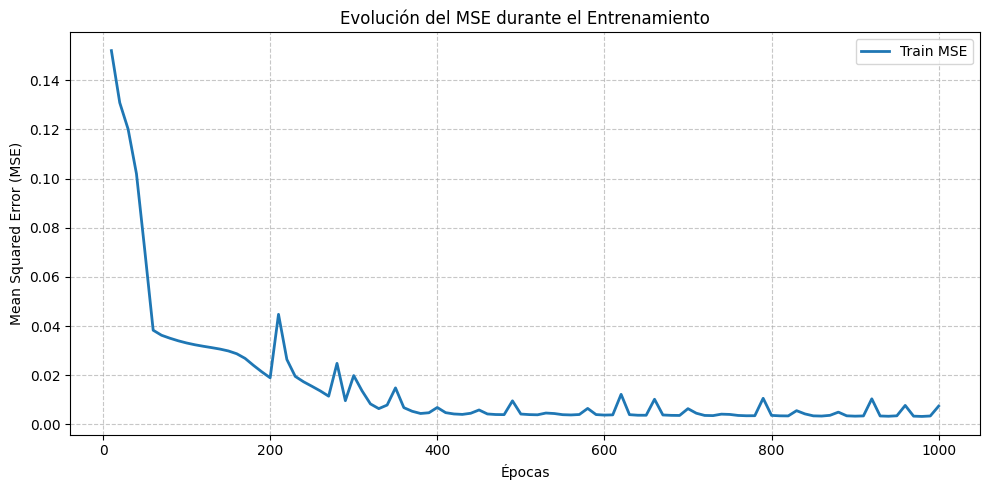

In [130]:
import matplotlib.pyplot as plt
    
# Generar la gráfica del MSE
plt.figure(figsize=(10, 5))

# Usamos len(train_losses) para que el eje X se ajuste automáticamente al número de épocas
plt.plot([10*x for x in range(1, len(train_losses) + 1)], train_losses, label='Train MSE', color='#1f77b4', linewidth=2)

plt.title('Evolución del MSE durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Mostrar la gráfica
plt.show()

Por lo que parece que en train no se puede aprender nada mucho mejor. Tal vez se podría minimzar el error en test entrenando por más épocas. O tal vez podría empeorar. 

## 1.4. Evaluación del modelo - Predicción de nuevos datos

Una vez entrenado el modelo, realizamos la predicción sobre el conjunto de test (20\% restante de la serie):

RMSE: 61.84


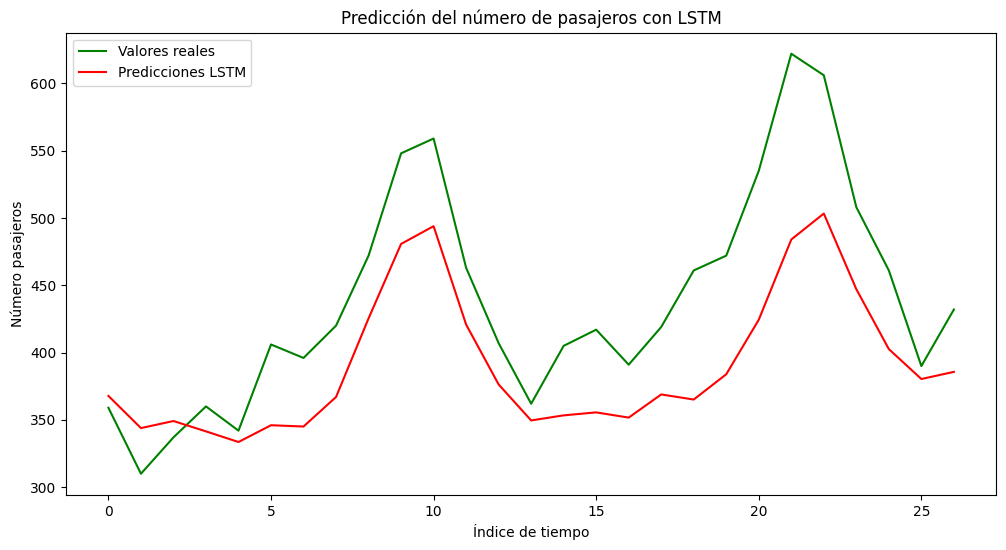

In [131]:
# 7. Predicción en el conjunto de prueba
from sklearn.metrics import mean_squared_error

model.eval()
X_test_unsqueezed = X_test.unsqueeze(-1)
predictions = model(X_test_unsqueezed).detach().numpy()

# Desescalado de las predicciones y los valores reales
y_test_descaled = scaler.inverse_transform(y_test.unsqueeze(-1).numpy())
predictions_descaled = scaler.inverse_transform(predictions)

# 8. Evaluación del modelo
mse = mean_squared_error(y_test_descaled, predictions_descaled)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

# 9. Visualización de los resultados
plt.figure(figsize=(12, 6))
plt.plot(y_test_descaled, label='Valores reales', color='green')
plt.plot(predictions_descaled, label='Predicciones LSTM', color='red')
plt.title("Predicción del número de pasajeros con LSTM")
plt.xlabel("Índice de tiempo")
plt.ylabel("Número pasajeros")
plt.legend()
plt.show()


**PREGUNTA 5: Realice diferentes entrenamientos modificando los hiperparámetros y compare los resultados. ¿Tienen sentido?**

RMSE: 17.14


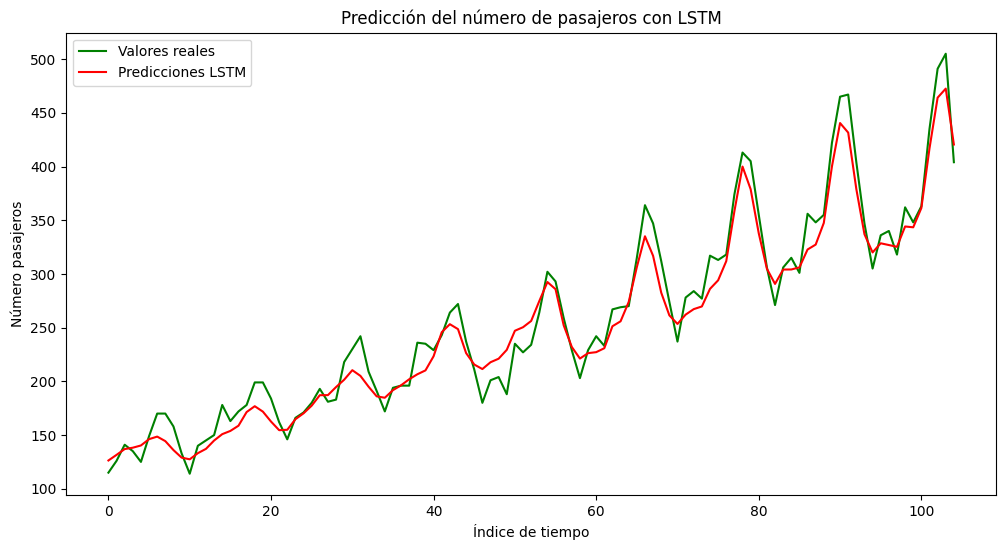

In [132]:
# 7. Predicción en el conjunto de entrenamiento ("cheating")
from sklearn.metrics import mean_squared_error

model.eval()
X_train_unsqueezed = X_train.unsqueeze(-1)
predictions = model(X_train_unsqueezed).detach().numpy()

# Desescalado de las predicciones y los valores reales
y_train_descaled = scaler.inverse_transform(y_train.unsqueeze(-1).numpy())
predictions_descaled = scaler.inverse_transform(predictions)

# 8. Evaluación del modelo
mse = mean_squared_error(y_train_descaled, predictions_descaled)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

# 9. Visualización de los resultados
plt.figure(figsize=(12, 6))
plt.plot(y_train_descaled, label='Valores reales', color='green')
plt.plot(predictions_descaled, label='Predicciones LSTM', color='red')
plt.title("Predicción del número de pasajeros con LSTM")
plt.xlabel("Índice de tiempo")
plt.ylabel("Número pasajeros")
plt.legend()
plt.show()

## 1.5. Aplicación a otros datos: series temporales financieras (opcional)

A continuación, podemos ampliar el trabajo elaborando un modelo basado en LSTM para los datos de series temporales financieras del S&P500 (usados en la práctica 5).

¿Hay diferencias a la hora de diseñar la red neuronal?

Text(0.5, 1.0, 'Serie temporal: SP500 (normalizada)')

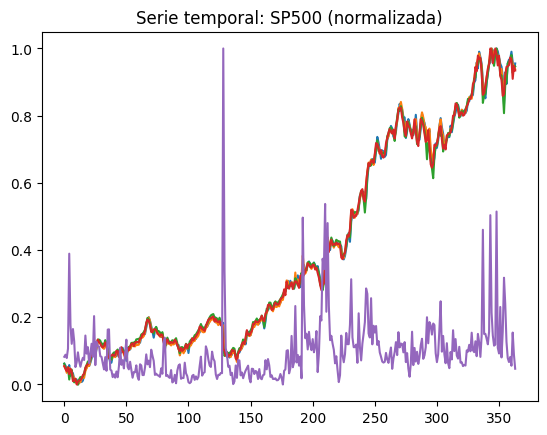

In [133]:
## Ejercicio opcional: SP500

# TODO EL PIPELINE

data = read_csv('stocks_1yr.csv', header=0, parse_dates=[0], index_col=0,
                date_format='%Y-%m')

data = data.drop(columns=['Name'])

scaler = MinMaxScaler(feature_range=(0, 1))
data_norm = scaler.fit_transform(data)

scaler_y = MinMaxScaler(feature_range=(0, 1))
scaler_y.fit(data[['close']])

plt.plot(data_norm)
plt.title('Serie temporal: SP500 (normalizada)')

In [134]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)  # Salida de la última capa LSTM
        hn = hn[-1]  # Seleccionamos el último estado oculto
        return self.fc(hn)

# Parámetros del modelo
input_size = 5
hidden_size = 20
num_layers = 2
output_size = 1

model = LSTMModel(input_size, hidden_size, num_layers, output_size)

In [135]:
seq_length = 12  # Ventana de 12 meses
data = data_norm
X, y = create_sequences(data, seq_length)

# División de datos en entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Conversión a tensores
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# 6. Entrenamiento del modelo
epochs = 300
batch_size = 32

train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        # Forward
        outputs = model(X_batch)
        loss = criterion(outputs.squeeze(), y_batch[:, 3])
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        train_losses.append(total_loss)

RMSE: 0.95 Dólares


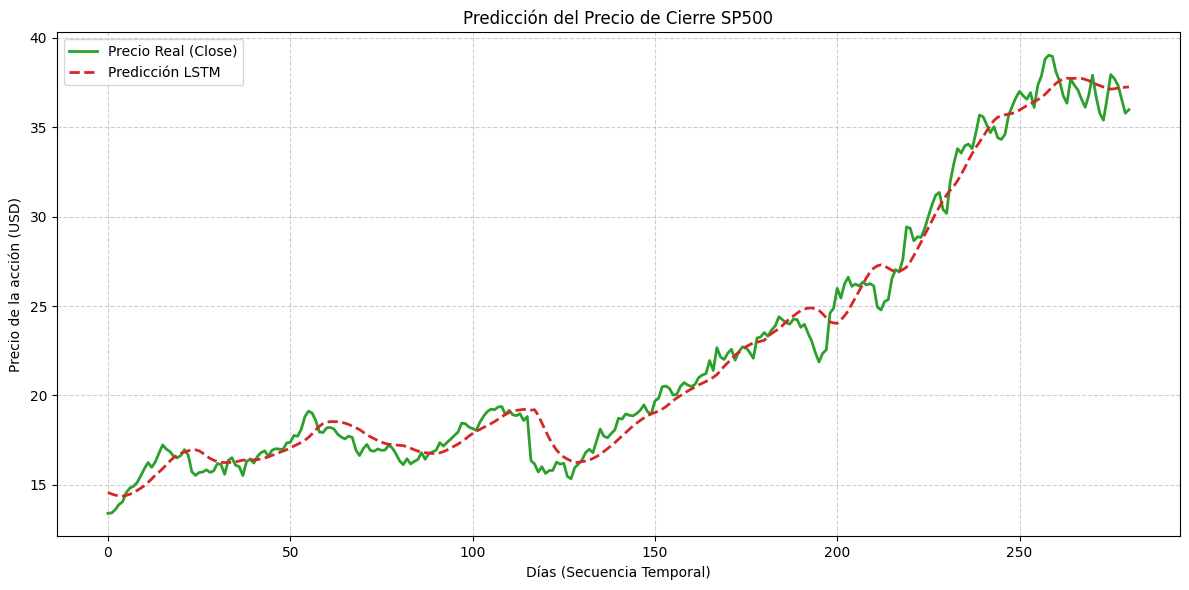

In [136]:
model.eval()

# Hacemos las predicciones (añadimos reshape para asegurar que sea 2D)
predictions = model(X_train).detach().numpy().reshape(-1, 1)

# Desescalado limpio, directo y sin trucos usando nuestro escalador dedicado
predictions_descaled = scaler_y.inverse_transform(predictions)

# Para desescalar y_train, extraemos la columna 3 y le damos forma 2D
y_train_close = y_train.numpy()[:, 3].reshape(-1, 1)
y_train_descaled = scaler_y.inverse_transform(y_train_close)

# 8. Evaluación del modelo
mse = mean_squared_error(y_train_descaled, predictions_descaled)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f} Dólares")

# 9. Visualización
plt.figure(figsize=(12, 6))
plt.plot(y_train_descaled, label='Precio Real (Close)', color='#2ca02c', linewidth=2)
plt.plot(predictions_descaled, label='Predicción LSTM', color='#d62728', linestyle='--', linewidth=2)
plt.title("Predicción del Precio de Cierre SP500")
plt.xlabel("Días (Secuencia Temporal)")
plt.ylabel("Precio de la acción (USD)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Parte 2: Detección de actividad de voz (VAD)




## 2.1. Introducción al procesamiento de señales temporales de voz


### 2.1.1. Descarga de ficheros de ejemplo

Primero vamos a descargar el audio de ejemplo de Moodle (**audio_sample.wav**) y ejecutar las siguientes  líneas de código, que nos permitirán subir el archivo a Google Colab desde el disco local:

Una vez cargado el fichero de audio, podemos escucharlo de la siguiente manera:

In [137]:
import IPython

wav_file_name = "audio_sample.wav"
print(wav_file_name)
IPython.display.Audio(wav_file_name)

audio_sample.wav


### 2.1.2. Lectura y representación de audio en Python

A continuación vamos a definir ciertas funciones para poder hacer manejo de  ficheros de audio en Python.

Comenzamos definiendo una función **read_recording** que leerá un fichero de audio WAV, normalizará la amplitud y devolverá el vector de muestras _signal_ y su frecuencia de muestreo _fs_.

In [138]:
import scipy.io.wavfile

def read_recording(wav_file_name):
  fs, signal = scipy.io.wavfile.read(wav_file_name)
  signal = signal/max(abs(signal)) # normalizes amplitude

  return fs, signal


Si ejecutamos la función anterior para el fichero de ejemplo, podemos ver la forma en la que se carga dicho fichero de audio en Python. Así, podemos obtener la frecuencia de muestreo y la longitud del fichero en número de muestras:

In [139]:
fs, signal = read_recording(wav_file_name)
print("Signal variable shape: " + str(signal.shape))
print("Sample rate: " + str(fs))
print("File length: " + str(len(signal)) + " samples")


Signal variable shape: (67072,)
Sample rate: 16000
File length: 67072 samples


**PREGUNTA 6: ¿Como obtendría la duración de la señal en segundos?**



In [140]:
print("File length: " + str(len(signal)/fs) + " seconds")

File length: 4.192 seconds


También podemos representar la señal y ver su forma de onda. Para ello, definimos la función **plot_signal** como sigue:

In [141]:
import matplotlib.pyplot as plt
import numpy as np

def plot_signal(signal, fs, ylabel="", title=""):
  dur = len(signal)/fs
  step = 1./fs
  t_axis = np.arange(0., dur, step)

  plt.plot(t_axis, signal)
  plt.xlim([0, dur])
  plt.ylabel(ylabel)
  plt.xlabel('Time (seconds)')
  plt.title(title)
  plt.grid(True)


Y utilizando la función anterior, obtenemos su representación (amplitud frente al tiempo):

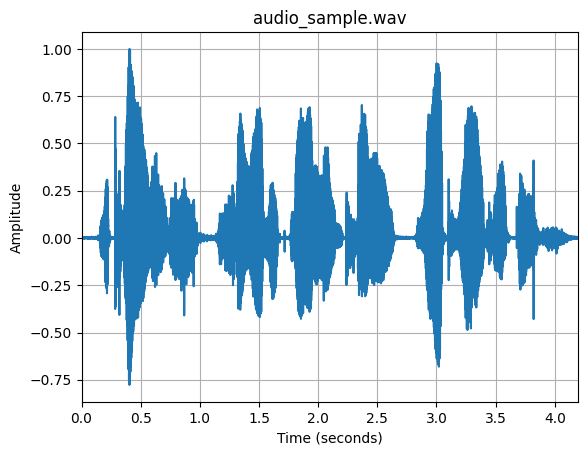

In [142]:
plot_signal(signal, fs, "Amplitude", wav_file_name)
plt.show()

### 2.1.3. Representación de etiquetas de actividad de voz

En esta práctica, vamos a desarrollar un detector de actividad de voz, que determinará qué segmentos de la señal de voz son realmente voz y cuáles silencio.

Por ello, vamos a ver dos ejemplos de etiquetas _ground truth_, que corresponden al fichero de audio de ejemplo.

Primero, descargamos de Moodle las etiquetas de voz/silencio que están en los ficheros **audio_sample_labels_1.voz** y **audio_sample_labels_2.voz** y las cargamos en Google Colab como en el caso anterior.

Estas etiquetas están guardadas en ficheros de texto y podemos cargarlas en Python de la siguiente manera:

In [143]:
labels_file_name = 'audio_sample_labels_1.voz'
voice_labels = np.loadtxt(labels_file_name)

Con el siguiente código, podemos representar la señal de voz así como sus etiquetas en la misma figura:

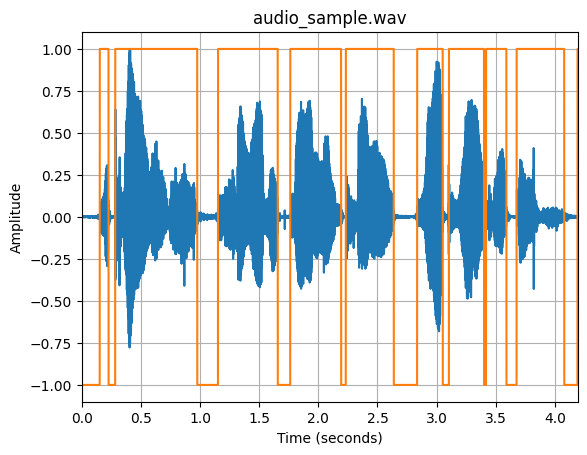

In [144]:
plot_signal(signal, fs)
plot_signal(voice_labels*2-1, fs, "Amplitude", wav_file_name)
plt.show()

Las etiquetas de voz/silencio provienen de distintos detectores de actividad de voz.

**PREGUNTA 7:**
- **¿Qué valores tienen las etiquetas? ¿Qué significan dichos valores?**

Simplemente muestran los tramos de la señal donde se clasifica silencio como un -1 y voz como un +1. 

- **¿Por qué se representa _voice_labels*2-1_?**

Porque es el fichero donde están etiquetados de forma más precisa los tramos de silencio. 

- **Represente la señal de voz junto con las etiquetas para ambos casos. ¿Qué diferencias observas? ¿A qué se puede deber?**

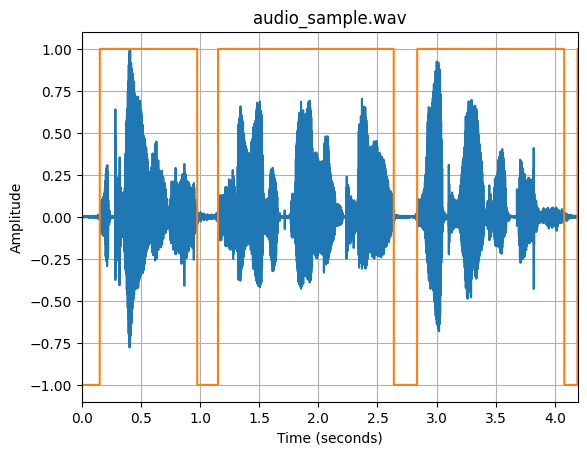

In [145]:
labels_file_name_2 = 'audio_sample_labels_2.voz'
voice_labels_2 = np.loadtxt(labels_file_name_2)

plot_signal(signal, fs)
plot_signal(voice_labels_2*2-1, fs, "Amplitude", wav_file_name)
plt.show()

En este caso, en el del segundo etiquetado, las etiquetas son más imprecisas clasificando el ruido, si bien lo hacen siguiendo la misma lógica. 

- **¿Qué cantidad de voz/silencio hay en cada etiquetado?**

Hay una mayor proporción de silencio en el primer etiquetado. Parece ser más preciso. 

### 2.1.4. Extracción de características

En la mayoría de sistemas de reconocimiento de patrones, un primer paso es la extracción de características. Esto consiste, a grandes rasgos, en obtener una representación de los datos de entrada, que serán utilizados para un posterior modelado.

En nuestro caso, vamos pasar de la señal en crudo _"raw"_ dada por las muestras (_signal_), a una secuencia de vectores de características que extraigan información a corto plazo de la misma y la representen. Esta sería la entrada a nuestro sistema de detección de voz basado en redes neuronales.

Para ver algunos ejemplos, vamos a utilizar la librería _librosa_ (https://librosa.org/doc/latest/index.html).

Dentro de esta librería, tenemos funciones para extraer distintos tipos de características de la señal de voz, como por ejemplo el espectrograma en escala Mel (_melspectrogram_).

Estas características a corto plazo, se extraen en ventanas de unos pocos milisegundos con o sin solapamiento.

Un ejemplo sería el siguiente:


In [146]:
import librosa

mel_spec = librosa.feature.melspectrogram(y=signal,sr=fs,n_mels=23,win_length=320,hop_length=160)

print(mel_spec.shape)
print(signal.shape)

(23, 420)
(67072,)


**PREGUNTA 8:**
- **¿Qué se obtiene de la función anterior?**

Se obtiene una matrizde dimensiones $23x420$, donde 23 corresponde con el número de bandas de frecuencia de Mel y 420 con el número de pasos temporales, correspondiente con el espectrograma de Mel de la señal de audio anterior.

- **¿Qué significan los valores de los parámetros _win_length_ y _hop_length_?**

_win_length_ determina el tamaño de cada ventana. Implica un trade-off entre resolución temporal y frecuencial. Fijarlo a 320 implica ventanas de $$ \frac{320}{f_s} = \frac{320 \text{ muestras}}{16000 \frac{ \text{muestras}}{\text{segundo}}} = 0.02s = 20\text{ms} $$

- **¿Qué dimensiones de _mel_spec_ obtienes? ¿Qué significan?**

Se obtienen dimensiones de mel $(23\times420)$. Como decíamosm, 420 corresponde con el número de frames temporales y 23 con el número de bandas de frecuencia de Mel. 23 es un valor arraigado en la literatura por convención. Suele ser un valor óptimo para captar las frecuencias de voz. 



De esta manera, podríamos obtener una parametrización de las señales para ser utilizadas como entrada a nuestra red neuronal.

Para los siguientes apartados, se proporcionan los vectores de características MFCC para una serie de audios que se utilizarán como conjunto de entrenamiento del modelo de VAD.

## 2.2. Detector de actividad de voz (Voice Activity Detector, VAD)



### 2.2.1. Descarga de los datos de entrenamiento

Primero vamos a descargar la lista de identificadores de los datos de entrenamiento de la práctica.

Para ello, necesitaremos descargar de Moodle el fichero **training_VAD.lst**, y ejecutar las siguientes líneas de código, que nos permitirán cargar el archivo a Google Colab desde el disco local:

A continuación cargamos los identificadores contenidos en el fichero en una lista en Python:

In [147]:
file_train_list = 'training_VAD.lst' # mat files containing data + labels
f = open(file_train_list, 'r')
train_list = f.read().splitlines()
f.close()

Podemos ver algunos de ellos (los primeros 10 identificatores) de la siguiente forma:

In [148]:
print(train_list[:10])

['features_labs_1.mat', 'features_labs_10.mat', 'features_labs_100.mat', 'features_labs_101.mat', 'features_labs_102.mat', 'features_labs_103.mat', 'features_labs_104.mat', 'features_labs_105.mat', 'features_labs_106.mat', 'features_labs_107.mat']


### 2.2.2. Definición del modelo

Utilizando nuevamente la librería Pytorch, vamos a definir un modelo inicial con una capa LSTM y una capa de salida. La capa de salida estará formada por una única neurona. La salida indicará la probabilidad de voz/silencio utilizando una función *sigmoid*.

In [149]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Model_1(nn.Module):
    def __init__(self, feat_dim=20):
        super(Model_1, self).__init__()

        self.lstm = nn.LSTM(feat_dim,256,batch_first=True,bidirectional=False)
        self.output = nn.Linear(256,1)

    def forward(self, x):

        out = self.lstm(x)[0]
        out = self.output(out)
        out = torch.sigmoid(out)

        return out.squeeze(-1)

**PREGUNTA 9: En este modelo, estamos utilizando una única neurona a la salida. ¿Hay alguna otra alternativa? ¿Se seguiría utilizando una función _sigmoid_?**

La idea es predecir para un problema de una única clase. Para ello, solo se necesita evalúar el resultado de una neurona sobre una función sigmoide. De esta forma, interpretamos la salida desde un enfoque probabilista y elegiremos como clase la más probable de entre las dos probabilidades. 

Si por el contrario fuera un problema multiclase en el que se pretende predecir distintos tipos de ruido, la salida no sería mononeuronal, sino de tantas neuronas como clases. Para un tal caso, la literatura acepta casi como única a la función softmax, una generalización de la sigmoide para el problema multiclase. 

Una vez definida la clase, podemos crear nuestra instancia del modelo y cargarlo en la GPU con el siguiente código:

In [150]:
model = Model_1(feat_dim=20)
model = model.to(torch.device("mps"))
print(model)

Model_1(
  (lstm): LSTM(20, 256, batch_first=True)
  (output): Linear(in_features=256, out_features=1, bias=True)
)


Nuestra variable _model_ contiene el modelo, y ya estamos listos para entrenarlo y evaluarlo.

### 2.2.3. Lectura y preparación de los datos para el entrenamiento

Como hemos visto anteriormente, nuestros datos están guardados en ficheros de Matlab (**.mat**). Cada uno de estos ficheros contiene una matriz **X** correspondiente a las secuencias de características MFCC (con sus derivadas de primer y segundo orden), y un vector **Y** con las etiquetas de voz/silencio correspondientes.

Veamos un ejemplo:


In [151]:
features_file = 'data/training_VAD/features_labs_1.mat'

import scipy.io
features = scipy.io.loadmat(features_file)['X']
labels = scipy.io.loadmat(features_file)['Y']

print(features.shape)
print(labels.shape)

(46654, 20)
(46654, 1)


Elija un fichero de entrenamiento y observe tanto el tamaño de **features** como de **labels**. Estas dimensiones se corresponden con la dimensionalidad de las características (20 coeficientes MFCC en nuestro caso) y la otra dimensión es la longitud de la secuencia en número de ventanas o frames.

In [152]:
features_file = 'data/training_VAD/features_labs_23.mat'

import scipy.io
features = scipy.io.loadmat(features_file)['X']
labels = scipy.io.loadmat(features_file)['Y']

print(features.shape)
print(labels.shape)

(52185, 20)
(52185, 1)


El entrenamiento del modelo se va a realizar mediante descenso por gradiente (o alguna de sus variantes) basado en _batches_.

Para preparar cada uno de estos _batches_ que servirán de entrada a nuestro modelo LSTM, debemos almacenar las características en secuencias de la misma longitud. El siguiente código lee las características (**get_fea**) y sus correspondientes etiquetas (**get_lab**) de un fragmento aleatorio del fichero de entrada.

In [153]:
import scipy.io
import numpy as np

def get_fea(segment, rand_idx):
    data = scipy.io.loadmat(segment)['X']
    if data.shape[0] <= length_segments:
        start_frame = 0
    else:
        start_frame = np.random.permutation(data.shape[0]-length_segments)[0]

    end_frame = np.min((start_frame + length_segments,data.shape[0]))
    rand_idx[segment] = start_frame
    feat = data[start_frame:end_frame,:]
    return feat[np.newaxis, :, :]


def get_lab(segment, rand_idx):
    data = scipy.io.loadmat(segment)['Y']
    start_frame = rand_idx[segment]
    end_frame = np.min((start_frame + length_segments, data.shape[0]))
    labs = data[start_frame:end_frame].flatten()
    return labs[np.newaxis,:]

**PREGUNTA 10: Analice las funciones anteriores detenidamente. ¿De qué tamaño son los fragmentos que se están leyendo? ¿Para qué sirve _rand_idx_?**

Los segmentos leídos tienen tamaños muy diversos. De ahí que _get_fea_ inicialice los segmentos en 0 si tienen longitud menor que 300 (seleccionada arbitrariamente, length_segments) y en un valor aleatorio (anterior a los 300 últimos) si tienen longitud mayor que 300, pero con longitud máxima de 300. Como a veces el índice donde empieza el segmento es aleatoria, necesita guardar de alguna forma ese índice para que las etiquetas también empiecen en él. Esa es la función de _rand_idx_. 

### 2.2.4. Entrenamiento del modelo
Una vez definidas las funciones de lectura de datos y preparación del formato que necesitamos para la entrada a la red LSTM, podemos utilizar el siguiente código para entrenarlo.

In [154]:
length_segments = 300
path_in_feat = 'data/training_VAD/'

loss_array = []
accuracy_array = []
epochs_array = []

from torch import optim

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

batch_size = 51
segment_sets = np.array_split(train_list, len(train_list)/batch_size)

max_iters = 20
for epoch in range(1, max_iters):
  print('Epoch: ',epoch)
  model.train()
  cache_loss = 0
  num_correct = 0
  num_total = 0

  for ii, segment_set in enumerate(segment_sets):
    rand_idx = {} 
    optimizer.zero_grad()

    # Create training batches
    train_batch = np.vstack([get_fea(path_in_feat + segment, rand_idx) for segment in segment_set])
    labs_batch = np.vstack([get_lab(path_in_feat + segment, rand_idx).astype(np.int16)  for segment in segment_set])
    assert len(labs_batch) == len(train_batch) # make sure that all frames have defined label
    # Shuffle the data and place them into Pytorch tensors
    shuffle = np.random.permutation(len(labs_batch))
    labs_batch = torch.tensor(labs_batch.take(shuffle, axis=0).astype("float32")).to(torch.device("mps"))
    train_batch = torch.tensor(train_batch.take(shuffle, axis=0).astype("float32")).to(torch.device("mps"))

    # Forward the data through the network
    outputs = model(train_batch)

    # Compute cost
    loss = criterion(outputs, labs_batch)

    # Backward step
    loss.backward()
    optimizer.step()
    cache_loss += loss.item()

    # Estimate the number of correct outputs (acc)
    num_correct += (outputs.round()).eq(labs_batch).sum().item()
    num_total += (train_batch.size()[0]*train_batch.size()[1])
    acc = num_correct * 1.0 / num_total

  epochs_array.append(epoch)
  loss_array.append(cache_loss/len(train_batch))
  accuracy_array.append(acc)
  print("Loss" + "/" + "accuracy: " + "{:.3f}".format(cache_loss/len(train_batch)) + '/' + "{:.3f}".format(acc))


Epoch:  1
Loss/accuracy: 0.119/0.703
Epoch:  2
Loss/accuracy: 0.088/0.804
Epoch:  3
Loss/accuracy: 0.066/0.853
Epoch:  4
Loss/accuracy: 0.061/0.878
Epoch:  5
Loss/accuracy: 0.062/0.877
Epoch:  6
Loss/accuracy: 0.056/0.889
Epoch:  7
Loss/accuracy: 0.055/0.887
Epoch:  8
Loss/accuracy: 0.052/0.893
Epoch:  9
Loss/accuracy: 0.048/0.905
Epoch:  10
Loss/accuracy: 0.048/0.904
Epoch:  11
Loss/accuracy: 0.047/0.905
Epoch:  12
Loss/accuracy: 0.046/0.911
Epoch:  13
Loss/accuracy: 0.044/0.911
Epoch:  14
Loss/accuracy: 0.043/0.914
Epoch:  15
Loss/accuracy: 0.046/0.909
Epoch:  16
Loss/accuracy: 0.046/0.909
Epoch:  17
Loss/accuracy: 0.048/0.904
Epoch:  18
Loss/accuracy: 0.039/0.922
Epoch:  19
Loss/accuracy: 0.044/0.916


**PREGUNTA 11:**
**Analizar el código anterior cuidadosamente y ejecutarlo. A continuación, responder a las siguientes cuestiones:**
- **¿Qué función de coste se está optimizando? Describir brevemente con ayuda de la documentación.**

BCELoss se refiere a la binary cross entropy; la entropía cruzada para un problema de clasificación binario. En concreto, para un batch de tamaño $N_{\text{batch}}$ se calcula como: $$\text{loss}(s(x;\theta)_k, y_k; \theta)=-\frac{1}{N}\sum_{n=1}^{N_{\text{batch}}}\sum_{k=1}^K y_k\operatorname{log}s(x;\theta)_k$$ que se reduce más concretamente a la expresión: $$\text{loss}(s(x;\theta)_k, y_k; \theta)=-\frac{1}{N}\sum_{n=1}^{N_{\text{batch}}} \operatorname{log}s(x;\theta)_{k=c_n}$$ Donde $c_n$ denota la clase real de la muestra $n$-ésima. 

- **¿Qué optimizador se ha definido?**

Se deine el optimizador Adam, que combina las ventajas de la técnica de _Momentum_ (un impulso inicial para los pasos de gradiente que permite al descenso más libertad de navegación por el mapa topológico de la función de pérdida dada la red) con _RMSprop_ (que ajusta la tasa de aprendizaje para cada parámetro, acelerando la convergencia).  

- **¿Para qué se utiliza _batch_size_?**

Para equilibrar la eficiencia computacional con la correctitud en los pasos de gradiente. Con batches muy grandes, permitimos a la red actualizar los pesos de forma más general y por tanto más precisa para el conjunto de datos. Sin embargo, batches muy grandes pueden implicar tiempos de cómputo inasumibles. En concreto, en una época, el gradiente se actualiza $N_{\text{batch}}$ veces. Si $N_{\text{batch}} = N_{\text{train}}$ y $N_{\text{train}}$ es demasiado grande, el tiempo de cómputo se dispararía.  

- **Describir brevemente la creación de los _batches_.**

Se crean batches de longitud 51. Para ello se emplea la función de _numpy_ _array_split_, que devuelve una lista de arrays de longitud igual al número de batches. Concretamente tantos como puedas formar en $N$ si van a ser de longitud 51. Esto es, por definición, el operador divisor, luego: $\frac{N}{51}$, tal y como se implementa.

- **¿Qué línea de código realiza el _forward pass_?**

outputs = model(train_batch)

- **¿Qué línea de código realiza el _backward pass_?**

loss.backward()

- **¿Cuántas iteraciones del algoritmo ha realizado? ¿Qué observa en la evolución de la función de coste?** 

Tendrá $N_{\text{batch}} \times \text{n\_epochs}$ iteraciones. Esto es $15 \times 51 = 765$ iteraciones.

- **Añada al código el cálculo de la precisión o _accuracy_, de tal manera que se muestre por pantalla dicho valor en cada iteración (similar a lo que ocurre con el valor del coste _loss_). Copiar el código en el informe y describir brevemente.**

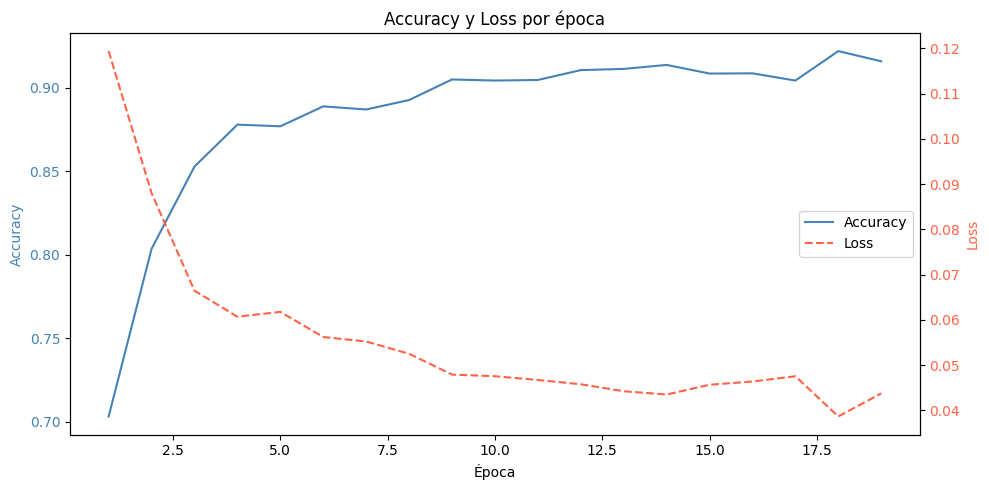

In [155]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(epochs_array, accuracy_array, color='steelblue', label='Accuracy')
ax1.set_xlabel('Época')
ax1.set_ylabel('Accuracy', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(epochs_array, loss_array, color='tomato', linestyle='--', label='Loss')
ax2.set_ylabel('Loss', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('Accuracy y Loss por época')
plt.tight_layout()
plt.show()

- **¿Qué valor de coste y _accuracy_ obtiene? ¿Cómo se puede mejorar?**

Se obtiene una pérdida de y un accuracy de . Para mejorarlo hay diversas opciones: 

- Aumentar la cantidad de muestras de datos manteniendo la arquitectura y el número de épocas. 

- Aumentar el tamaño y la profundidad de la red manteniendo el tamaño de las muestras de datos y el número de épocas.

- Aumentar en la medida de lo posible todos los parámetros que estamos contando como hiperparámetros.

- Jugar con otros hiperparámetros como el learning rate o el batch size. 

- Entrenar por muchas épocas, esperando que, de alguna forma, se dé el fenomeno de double descent a partir de una época umbral (umbral de interpolación). 

### 2.2.5. Evaluación del modelo: un único fichero de test

Una vez entrenado el modelo, vamos a evaluarlo en un ejemplo en concreto.

Descargue de Moodle el fichero **audio_sample_test.wav**, con sus correspondientes características y etiquetas **audio_sample_test.mat** y evalúe el rendimiento en el mismo, observando por ejemplo el _accuracy_ obtenido.


In [156]:
import scipy.io
import torch
import numpy as np

# Cargar características y etiquetas del fichero de test
mat_test = scipy.io.loadmat('audio_sample_test.mat')
features_test = mat_test['X']          # (T, 20)
labels_test   = mat_test['Y'].flatten() # (T,)

# Preparar tensor: (1, T, 20)
X_test_tensor = torch.tensor(features_test[np.newaxis, :, :], dtype=torch.float32).to('mps')

# Forward pass
model.eval()
with torch.no_grad():
    outputs_test = model(X_test_tensor)  # (1, T)

preds = outputs_test.squeeze().cpu().numpy()
preds_binary = np.round(preds)

# Accuracy
acc_test = np.mean(preds_binary == labels_test[:len(preds_binary)])
loss_test = criterion(outputs_test.squeeze(), torch.tensor(labels_test[:len(preds_binary)], dtype=torch.float32).to('mps'))
print(f"Test Accuracy: {acc_test:.4f}")
print(f"Test Loss:     {loss_test.item():.4f}")


Test Accuracy: 0.9114
Test Loss:     0.2627




A continuación, represente 10 segundos de dicho audio, así como sus etiquetas de _ground_truth_ y las obtenidas con su modelo.

**PREGUNTA 12: Visualmente, ¿es bueno el modelo?**
**También puede escuchar el audio para evaluarlo cualitativamente.**


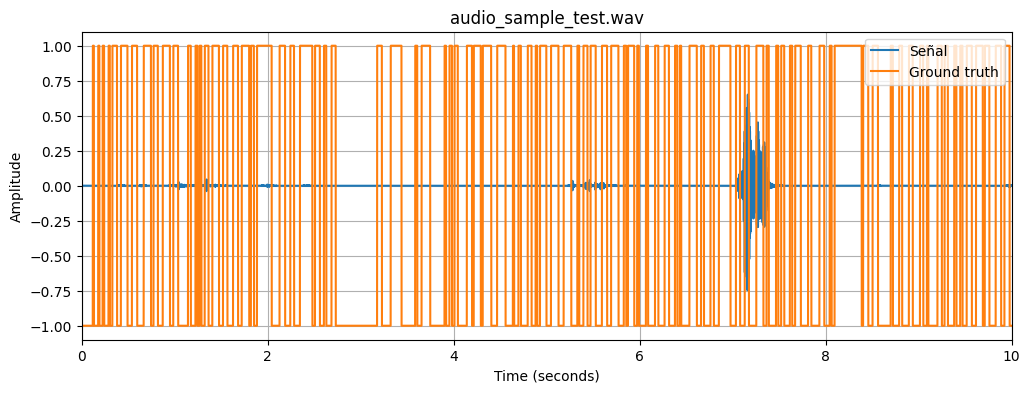

In [157]:
fs, raw = read_recording('audio_sample_test.wav')
N = fs * 10

# Resamplear etiquetas ground truth y predicciones al número de muestras de audio
T_pred = len(preds_binary)
labels_resampled = np.interp(np.linspace(0, 1, N), np.linspace(0, 1, len(labels_test)), labels_test)
preds_resampled  = np.interp(np.linspace(0, 1, N), np.linspace(0, 1, T_pred), preds_binary)

plt.figure(figsize=(12, 4))
plot_signal(raw[:N], fs)
plot_signal(labels_resampled * 2 - 1, fs, "Amplitude", "audio_sample_test.wav")
# plot_signal(preds_resampled  * 2 - 1, fs)
plt.legend(['Señal', 'Ground truth', 'Predicción modelo'])
plt.show()

### 2.2.6. Evaluación del modelo: conjunto de validación





Escriba ahora el código necesario para evaluar el modelo anterior en el conjunto de datos de validación, para su última época.

Tenga en cuenta que si quiere realizar el forward para todos los datos de validación de una vez, necesitará que todas las secuencias sean de la misma longitud. Como aproximación, puede escoger unos pocos segundos de cada fichero como se hace en el entrenamiento.

In [158]:
# Cargar lista de validación
file_valid_list = 'valid_VAD.lst'
with open(file_valid_list, 'r') as f:
    valid_list = f.read().splitlines()

path_in_feat_valid = 'data/valid_VAD/'
segment_sets_val = np.array_split(valid_list, max(1, len(valid_list) // batch_size))

model.eval()
cache_loss_val = 0
num_correct_val = 0
num_total_val   = 0

with torch.no_grad():
    for segment_set in segment_sets_val:
        rand_idx = {}
        val_batch = np.vstack([get_fea(path_in_feat_valid + seg, rand_idx) for seg in segment_set])
        labs_val  = np.vstack([get_lab(path_in_feat_valid + seg, rand_idx).astype(np.int16) for seg in segment_set])

        labs_tensor = torch.tensor(labs_val.astype("float32")).to('mps')
        val_tensor  = torch.tensor(val_batch.astype("float32")).to('mps')

        outputs_val = model(val_tensor)
        loss_val    = criterion(outputs_val, labs_tensor)
        cache_loss_val += loss_val.item()

        num_correct_val += (outputs_val.round()).eq(labs_tensor).sum().item()
        num_total_val   += val_tensor.size(0) * val_tensor.size(1)

acc_val = num_correct_val / num_total_val
print(f"Validation Loss: {cache_loss_val / len(segment_sets_val):.4f} | Accuracy: {acc_val:.4f}")


Validation Loss: 0.2285 | Accuracy: 0.9119


**PREGUNTA 13: ¿Qué rendimiento (loss y accuracy) obtiene con este modelo (_Model_1_) en entrenamiento y en validación?**

## 2.3. Comparación de modelos



### 2.3.1. Redes LSTM bidireccionales

En este apartado, vamos a partir del modelo inicial (_Model_1_) y modificarlo para que la capa LSTM sea bidireccional (_Model_1B_).

Entrene el nuevo modelo y compare el resultado con el modelo inicial.

In [159]:
# --- Definición de Model_1B (LSTM bidireccional) ---
class Model_1B(nn.Module):
    def __init__(self, feat_dim=20):
        super(Model_1B, self).__init__()
        # bidirectional=True duplica el tamaño de salida -> 512
        self.lstm   = nn.LSTM(feat_dim, 256, batch_first=True, bidirectional=True)
        self.output = nn.Linear(512, 1)

    def forward(self, x):
        out = self.lstm(x)[0]
        out = self.output(out)
        out = torch.sigmoid(out)
        return out.squeeze(-1)

model_1b    = Model_1B(feat_dim=20).to('mps')
criterion_1b = nn.BCELoss()
optimizer_1b = optim.Adam(model_1b.parameters(), lr=0.001)

# --- Entrenamiento ---
for epoch in range(1, max_iters):
    print('Epoch:', epoch)
    model_1b.train()
    cache_loss, num_correct, num_total = 0, 0, 0

    for segment_set in segment_sets:
        rand_idx = {}
        optimizer_1b.zero_grad()

        train_batch = np.vstack([get_fea(path_in_feat + seg, rand_idx) for seg in segment_set])
        labs_batch  = np.vstack([get_lab(path_in_feat + seg, rand_idx).astype(np.int16) for seg in segment_set])

        shuffle     = np.random.permutation(len(labs_batch))
        labs_batch  = torch.tensor(labs_batch.take(shuffle, axis=0).astype("float32")).to('mps')
        train_batch = torch.tensor(train_batch.take(shuffle, axis=0).astype("float32")).to('mps')

        outputs = model_1b(train_batch)
        loss    = criterion_1b(outputs, labs_batch)
        loss.backward()
        optimizer_1b.step()
        cache_loss  += loss.item()
        num_correct += (outputs.round()).eq(labs_batch).sum().item()
        num_total   += train_batch.size(0) * train_batch.size(1)

    print(f"Loss / Accuracy: {cache_loss/len(train_batch):.4f} / {num_correct/num_total:.4f}")

# --- Validación ---
model_1b.eval()
cache_loss_val, num_correct_val, num_total_val = 0, 0, 0

with torch.no_grad():
    for segment_set in segment_sets_val:
        rand_idx = {}
        val_batch   = np.vstack([get_fea(path_in_feat_valid + seg, rand_idx) for seg in segment_set])
        labs_val    = np.vstack([get_lab(path_in_feat_valid + seg, rand_idx).astype(np.int16) for seg in segment_set])
        labs_tensor = torch.tensor(labs_val.astype("float32")).to('mps')
        val_tensor  = torch.tensor(val_batch.astype("float32")).to('mps')

        outputs_val      = model_1b(val_tensor)
        cache_loss_val  += criterion_1b(outputs_val, labs_tensor).item()
        num_correct_val += (outputs_val.round()).eq(labs_tensor).sum().item()
        num_total_val   += val_tensor.size(0) * val_tensor.size(1)

print(f"Model_1B Val Loss: {cache_loss_val/len(segment_sets_val):.4f} | Accuracy: {num_correct_val/num_total_val:.4f}")


Epoch: 1
Loss / Accuracy: 0.1148 / 0.7154
Epoch: 2
Loss / Accuracy: 0.0809 / 0.8231
Epoch: 3
Loss / Accuracy: 0.0588 / 0.8778
Epoch: 4
Loss / Accuracy: 0.0529 / 0.8919
Epoch: 5
Loss / Accuracy: 0.0459 / 0.9049
Epoch: 6
Loss / Accuracy: 0.0505 / 0.8998
Epoch: 7
Loss / Accuracy: 0.0412 / 0.9211
Epoch: 8
Loss / Accuracy: 0.0410 / 0.9149
Epoch: 9
Loss / Accuracy: 0.0444 / 0.9102
Epoch: 10
Loss / Accuracy: 0.0419 / 0.9153
Epoch: 11
Loss / Accuracy: 0.0336 / 0.9309
Epoch: 12
Loss / Accuracy: 0.0367 / 0.9273
Epoch: 13
Loss / Accuracy: 0.0398 / 0.9228
Epoch: 14
Loss / Accuracy: 0.0364 / 0.9290
Epoch: 15
Loss / Accuracy: 0.0409 / 0.9219
Epoch: 16
Loss / Accuracy: 0.0367 / 0.9297
Epoch: 17
Loss / Accuracy: 0.0349 / 0.9304
Epoch: 18
Loss / Accuracy: 0.0327 / 0.9373
Epoch: 19
Loss / Accuracy: 0.0373 / 0.9287
Model_1B Val Loss: 0.2027 | Accuracy: 0.9208


**PREGUNTA 14:**
- **Explique brevemente la diferencia entre una capa LSTM y una BLSTM (bidirectional LSTM).**

Una BLSTM es un caso particular de LSTM en el que no solo se tienen en cuenta referencias pasadas, sino que también las futuras, a la hora de hacer predicciones. 

- **¿Qué modelo obtiene un mejor resultado sobre los datos de validación? ¿Por qué puede ocurrir esto?**

El mejor resultado lo obtiene, de largo, la LSTM bidireccional. Este resultado tiene una interpretación clara a priori (para este caso particular de audio): una predicción de un fonema actual no solo tiene que ver con los fonemas pasados. Lo que haces después de emitir un fonema $x_t$, el conjunto $\{x_{t+1}, x_{t+2}, \cdots, x_{t+k}\}$ puede tener lo mismo que decir acerca del fonema $x_t$ que los anteriores, el conjunto $\{x_{t-k}, \cdots, x_{t-2}, x_{t-1}\}$. De ahí que al tener en cuenta ambas direcciones, las predicciones sean más robustas. Se aprende nueva información que puede ser relevante y que, de hecho, marca la diferencia. 

### 2.3.2. Modelo "más profundo"

En este apartado, vamos a partir nuevamente del modelo _Model_1_ y vamos a añadir una segunda capa LSTM tras la primera, con el mismo tamaño y configuración, definiendo un nuevo modelo _Model_2_.

Entrénelo y compare los resultados.

In [160]:
# --- Definición de Model_2 (2 capas LSTM apiladas) ---
class Model_2(nn.Module):
    def __init__(self, feat_dim=20):
        super(Model_2, self).__init__()
        self.lstm1  = nn.LSTM(feat_dim, 256, batch_first=True, bidirectional=False)
        self.lstm2  = nn.LSTM(256,       256, batch_first=True, bidirectional=False)
        self.output = nn.Linear(256, 1)

    def forward(self, x):
        out = self.lstm1(x)[0]
        out = self.lstm2(out)[0]
        out = self.output(out)
        out = torch.sigmoid(out)
        return out.squeeze(-1)

model_2     = Model_2(feat_dim=20).to('mps')
criterion_2  = nn.BCELoss()
optimizer_2  = optim.Adam(model_2.parameters(), lr=0.001)

# --- Entrenamiento ---
for epoch in range(1, max_iters):
    print('Epoch:', epoch)
    model_2.train()
    cache_loss, num_correct, num_total = 0, 0, 0

    for segment_set in segment_sets:
        rand_idx = {}
        optimizer_2.zero_grad()

        train_batch = np.vstack([get_fea(path_in_feat + seg, rand_idx) for seg in segment_set])
        labs_batch  = np.vstack([get_lab(path_in_feat + seg, rand_idx).astype(np.int16) for seg in segment_set])

        shuffle     = np.random.permutation(len(labs_batch))
        labs_batch  = torch.tensor(labs_batch.take(shuffle, axis=0).astype("float32")).to('mps')
        train_batch = torch.tensor(train_batch.take(shuffle, axis=0).astype("float32")).to('mps')

        outputs = model_2(train_batch)
        loss    = criterion_2(outputs, labs_batch)
        loss.backward()
        optimizer_2.step()
        cache_loss  += loss.item()
        num_correct += (outputs.round()).eq(labs_batch).sum().item()
        num_total   += train_batch.size(0) * train_batch.size(1)

    print(f"Loss / Accuracy: {cache_loss/len(train_batch):.4f} / {num_correct/num_total:.4f}")

# --- Validación ---
model_2.eval()
cache_loss_val, num_correct_val, num_total_val = 0, 0, 0

with torch.no_grad():
    for segment_set in segment_sets_val:
        rand_idx = {}
        val_batch   = np.vstack([get_fea(path_in_feat_valid + seg, rand_idx) for seg in segment_set])
        labs_val    = np.vstack([get_lab(path_in_feat_valid + seg, rand_idx).astype(np.int16) for seg in segment_set])
        labs_tensor = torch.tensor(labs_val.astype("float32")).to('mps')
        val_tensor  = torch.tensor(val_batch.astype("float32")).to('mps')

        outputs_val      = model_2(val_tensor)
        cache_loss_val  += criterion_2(outputs_val, labs_tensor).item()
        num_correct_val += (outputs_val.round()).eq(labs_tensor).sum().item()
        num_total_val   += val_tensor.size(0) * val_tensor.size(1)

print(f"Model_2 Val Loss: {cache_loss_val/len(segment_sets_val):.4f} | Accuracy: {num_correct_val/num_total_val:.4f}")


Epoch: 1
Loss / Accuracy: 0.1138 / 0.7170
Epoch: 2
Loss / Accuracy: 0.0738 / 0.8539
Epoch: 3
Loss / Accuracy: 0.0612 / 0.8842
Epoch: 4
Loss / Accuracy: 0.0589 / 0.8879
Epoch: 5
Loss / Accuracy: 0.0589 / 0.8873
Epoch: 6
Loss / Accuracy: 0.0561 / 0.8903
Epoch: 7
Loss / Accuracy: 0.0516 / 0.8992
Epoch: 8
Loss / Accuracy: 0.0556 / 0.8904
Epoch: 9
Loss / Accuracy: 0.0578 / 0.8853
Epoch: 10
Loss / Accuracy: 0.0493 / 0.9031
Epoch: 11
Loss / Accuracy: 0.0457 / 0.9088
Epoch: 12
Loss / Accuracy: 0.0458 / 0.9109
Epoch: 13
Loss / Accuracy: 0.0476 / 0.9052
Epoch: 14
Loss / Accuracy: 0.0504 / 0.9037
Epoch: 15
Loss / Accuracy: 0.0525 / 0.8926
Epoch: 16
Loss / Accuracy: 0.0486 / 0.8986
Epoch: 17
Loss / Accuracy: 0.0450 / 0.9082
Epoch: 18
Loss / Accuracy: 0.0474 / 0.9061
Epoch: 19
Loss / Accuracy: 0.0449 / 0.9129
Model_2 Val Loss: 0.2941 | Accuracy: 0.8822


**PREGUNTA 15:**
- **¿Qué modelo obtiene un mejor resultado sobre los datos de validación, _Model_1_ o _Model_2_? ¿Por qué puede ocurrir esto?**

A penas hay diferencia entre uno y otro. Por mucho que la red neuronal se adapte mejor a los datos en train (tiene menor loss), esto a penas supone una mejora en test. Podría ser incluso negativo. Esto se debe al sobreajuste que puede causar una complejidad excesiva de la arquitectura de la red, que con demasiados parámetros podrían estar aprendiendo patrones demasiado concretos del conjunto de train. Esto causa problemas de generalización a posteriori.  

- **Y con respecto a _Model_1B_, ¿cuál es mejor?**

Claramente _Model_1B_ tiene un mejor rendimiento en cuanto a accuracy. Si bien su arquitectura es menos densa, es más compleja en cuanto a la medida en la que se adapta al problema que tratamos de resolver. 